(214, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None
               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.81

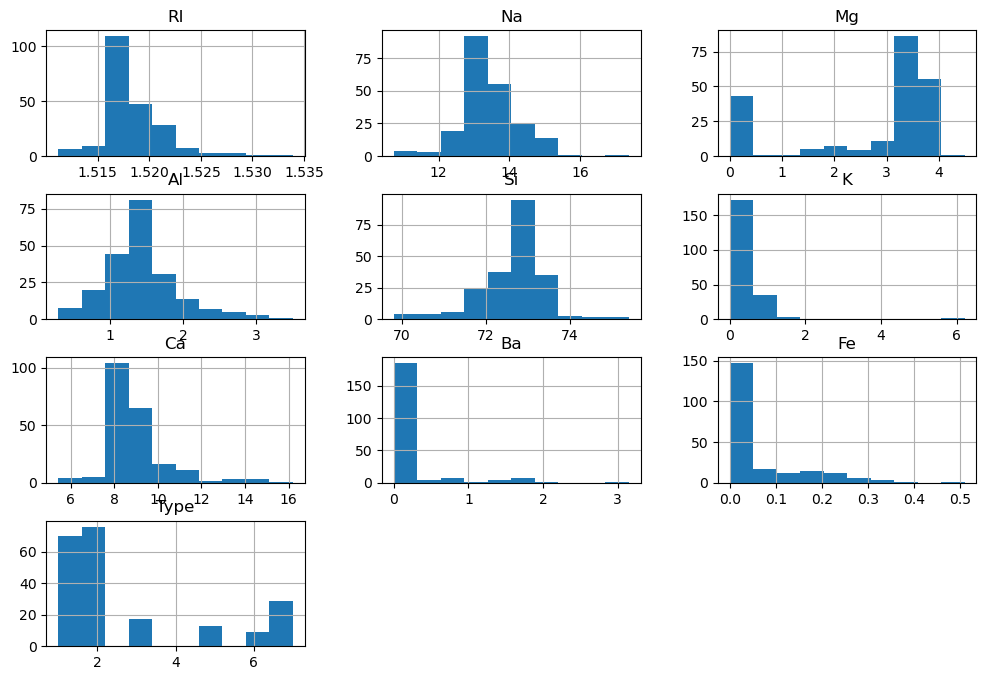

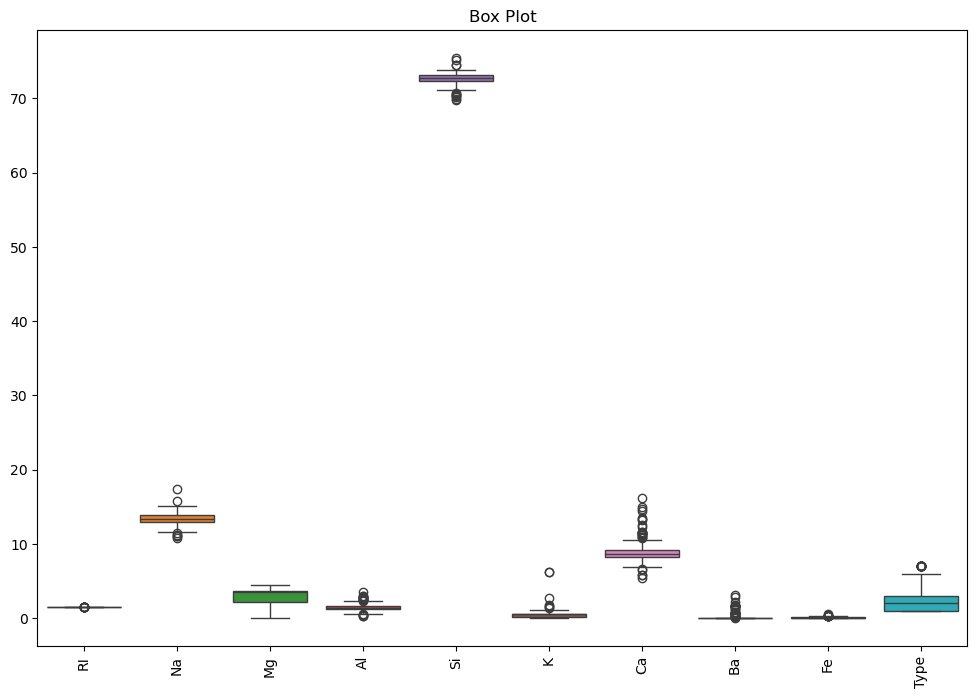

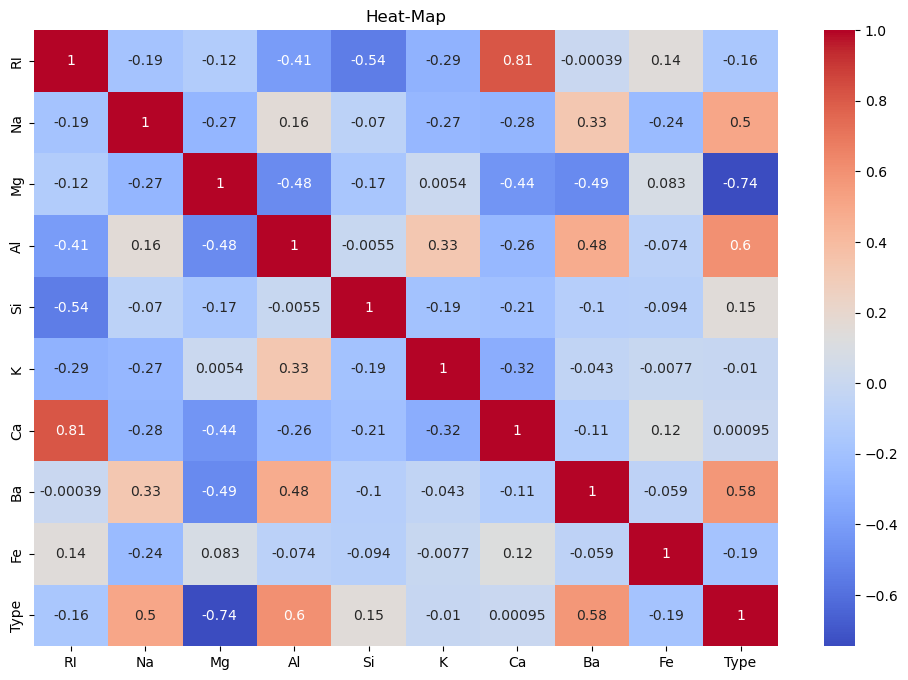

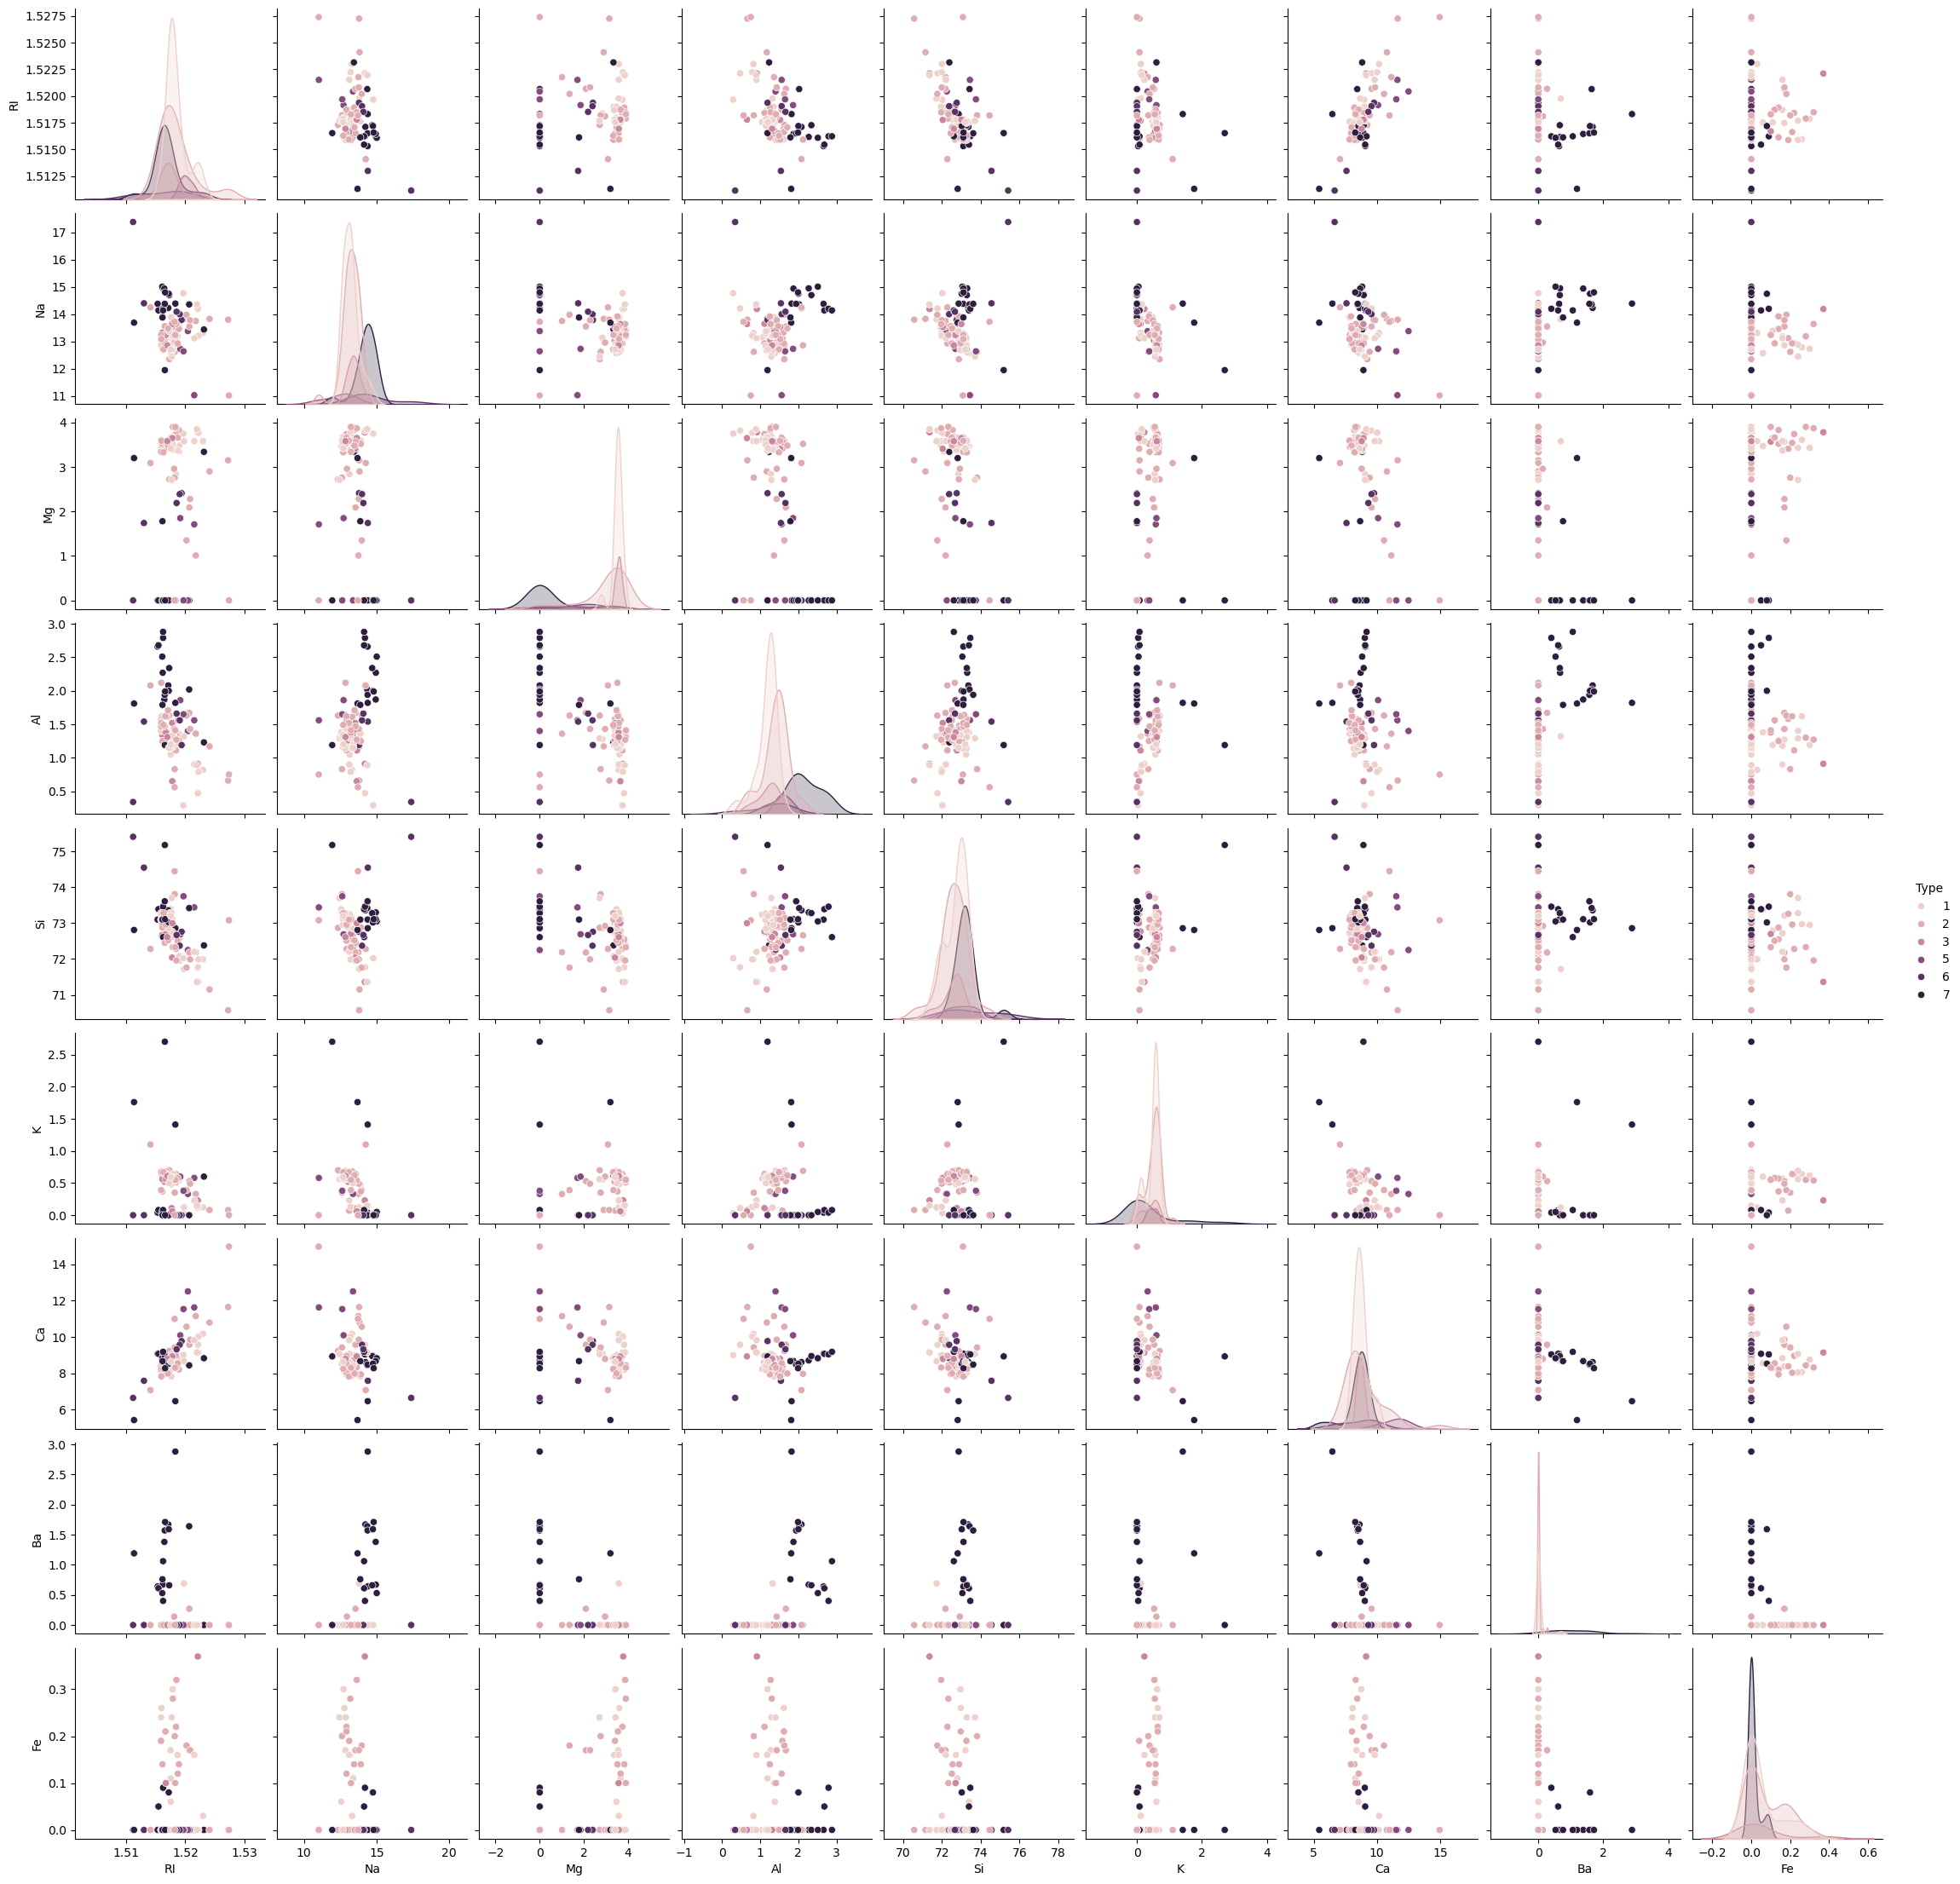

MinMax Scaling Applied
Type
2    0.355140
1    0.327103
7    0.135514
3    0.079439
5    0.060748
6    0.042056
Name: proportion, dtype: float64
Accuracy: 0.813953488372093

Classification Report:

              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.79      0.73      0.76        15
           3       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.81        43
   macro avg       0.87      0.85      0.84        43
weighted avg       0.83      0.81      0.81        43


Confusion Matrix:

[[12  2  0  0  0  0]
 [ 3 11  0  0  1  0]
 [ 1  0  2  0  0  0]
 [ 0  0  0  3  0  0]
 [ 0  0  0  0  2  0]
 [ 0  1  0  0  0  5]]


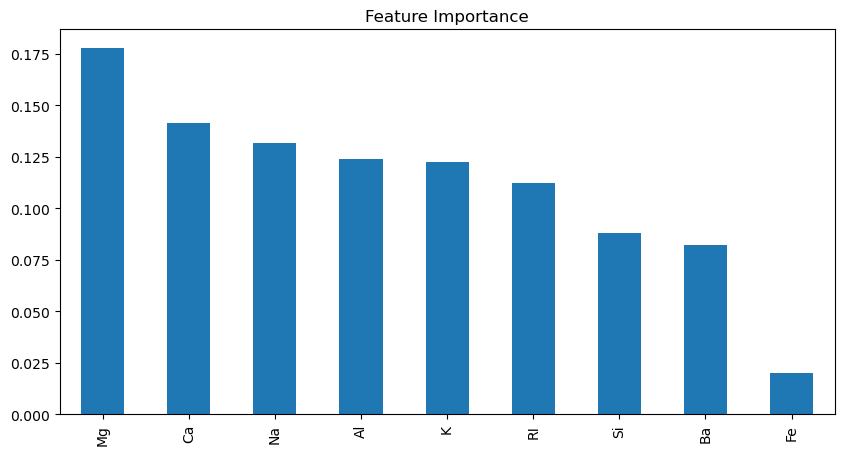


-----BAGGING RESULTS-----
              precision    recall  f1-score   support

           1       0.79      0.79      0.79        14
           2       0.85      0.73      0.79        15
           3       0.67      0.67      0.67         3
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       0.86      1.00      0.92         6

    accuracy                           0.79        43
   macro avg       0.75      0.81      0.77        43
weighted avg       0.79      0.79      0.79        43



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



-----BOOSTING RESULTS-----
              precision    recall  f1-score   support

           1       0.54      0.93      0.68        14
           2       0.42      0.33      0.37        15
           3       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         3
           6       0.50      1.00      0.67         2
           7       1.00      0.50      0.67         6

    accuracy                           0.53        43
   macro avg       0.41      0.46      0.40        43
weighted avg       0.48      0.53      0.48        43


-----MODEL COMPARISON-----
           Model  Accuracy
0  Random Forest  0.813953
1        Bagging  0.790698
2       Boosting  0.534884


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [3]:
import numpy as np
import pandas as pd

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_excel(
    r"C:\Users\NIKHIL\Downloads\data science assignment\data science assignment\glass.xlsx",
    sheet_name="glass"
)

# ==========================================
# DATA OVERVIEW
# ==========================================

print(df.shape)

print(df.info())

print(df.describe())

print(df.head())

print(df.isnull().sum())

print(df["Type"].value_counts())

# ==========================================
# VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(12,8))

plt.show()

plt.figure(figsize=(12,8))

sns.boxplot(df)

plt.xticks(rotation=90)

plt.title("Box Plot")

plt.show()

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Heat-Map")

plt.show()

# Pair Plot
sns.pairplot(df.sample(100), hue="Type")

plt.show()

# ==========================================
# FEATURES & TARGET
# ==========================================

X = df.drop("Type", axis=1)

y = df["Type"]

X = X.fillna(X.mean())

# ==========================================
# FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Standard Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# MinMax Scaling
mm_scaler = MinMaxScaler()

X_mm = mm_scaler.fit_transform(X)

print("MinMax Scaling Applied")

print(y.value_counts(normalize=True))

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# RANDOM FOREST MODEL
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

# ==========================================
# MODEL EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")

print(confusion_matrix(y_test, y_pred))

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importances = rf.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X.columns
)

feature_importance.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Feature Importance")

plt.show()

# ==========================================
# BAGGING
# ==========================================

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)

bag_pred = bagging.predict(X_test)

print("\n-----BAGGING RESULTS-----")

print(classification_report(y_test, bag_pred))

# ==========================================
# BOOSTING
# ==========================================

from sklearn.ensemble import AdaBoostClassifier

boosting = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

boosting.fit(X_train, y_train)

boost_pred = boosting.predict(X_test)

print("\n-----BOOSTING RESULTS-----")

print(classification_report(y_test, boost_pred))

# ==========================================
# MODEL COMPARISON
# ==========================================

comparison = pd.DataFrame({
    "Model": ["Random Forest", "Bagging", "Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, bag_pred),
        accuracy_score(y_test, boost_pred)
    ]
})

print("\n-----MODEL COMPARISON-----")

print(comparison)

# Interview Questions

1. What is Random Forest?
Random Forest is an ensemble learning algorithm that combines multiple decision trees for better accuracy and reduced overfitting.

2. What is Bagging?
Bagging is an ensemble technique where multiple models are trained on random subsets of data and combined together.

3. What is Boosting?
Boosting is an ensemble technique where models are trained sequentially to correct previous errors.

4. What is Feature Importance?
Feature importance indicates how useful a feature is in making predictions in Random Forest.

5. What is the difference between Bagging and Boosting?
Bagging trains models independently, while Boosting trains models sequentially focusing on previous mistakes.